# CSV_file_Hitters_Multinomial_Classification_Keras_MLP

### Keras 모델을 이용하여, 타석수(AtBat), 안타수(Hitts)와 홈런수(HmRun) 등으로 급여(Salary)를 상중하로 예측하는 Multinomial Classification을 MLP로 구현하라
### (Colab을 사용하는 경우 "files/Hitters.csv"를 "내 드라이브/files/"에 복사)

>### Load modules

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))
print("Pandas Version :{}".format(pd.__version__))

NumPy Version :1.26.4
TensorFlow Version :2.18.0
Matplotlib Version :3.10.0
Pandas Version :2.2.2


> ### Load Data

In [2]:
colab=True
try:
  from google.colab import drive
except:
  colab =False
if colab :
    drive.mount('/content/drive')
    print('g-drive mounted.')
else : print('local drive.')

Mounted at /content/drive
g-drive mounted.


In [3]:
# file path: 다른 경로에 실습파일을 복사했다면, 아래 경로를 수정하세요

if colab :
  files_path = '/content/drive/MyDrive/[SOL]LAB_07_CSV_file_Hitters_Multinomial_Classification_Keras_MLP/files/Hitters.csv'
else :
  files_path = '../files/Hitters.csv'

>### < Hitters.csv의 주요 column >
>#### AtBat : 타석수
>#### Hits : 안타수
>#### HmRun : 홈런수
>#### runs : 타점
>#### Warks : 볼넷
>#### Salary : 급여

In [4]:
# Hitters.csv 파일 읽기
# pd.set_option('display.max_rows', None) ## 모든 행을 출력한다.
df = pd.read_csv(files_path)
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


> ### csv 파일 전처리

In [5]:
# 특정 column만 가져오기
df = df.loc[:, ['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'Salary']]
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,Salary
0,293,66,1,30,29,14,293,66,1,30,29,14,NaN
1,315,81,7,24,38,39,3449,835,69,321,414,375,475.0
2,479,130,18,66,72,76,1624,457,63,224,266,263,480.0
3,496,141,20,65,78,37,5628,1575,225,828,838,354,500.0
4,321,87,10,39,42,30,396,101,12,48,46,33,91.5


In [6]:
# Missing 데이터 제거
df = df.dropna()
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,Salary
1,315,81,7,24,38,39,3449,835,69,321,414,375,475.0
2,479,130,18,66,72,76,1624,457,63,224,266,263,480.0
3,496,141,20,65,78,37,5628,1575,225,828,838,354,500.0
4,321,87,10,39,42,30,396,101,12,48,46,33,91.5
5,594,169,4,74,51,35,4408,1133,19,501,336,194,750.0


In [7]:
# Salary를 상(2), 중(1), 하(0)으로 구분
df.loc[df['Salary'] >= 600, 'Salary2'] = 2
df.loc[(df['Salary'] >= 250) & (df['Salary'] < 600), 'Salary2'] = 1
df.loc[df['Salary'] < 250, 'Salary2'] = 0
df.head()

<ipython-input-7-43472440bb29>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[df['Salary'] >= 600, 'Salary2'] = 2


,AtBat,Hits,HmRun,Runs,RBI,Walks,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,Salary,Salary2
1,315,81,7,24,38,39,3449,835,69,321,414,375,475.0,1.0
2,479,130,18,66,72,76,1624,457,63,224,266,263,480.0,1.0
3,496,141,20,65,78,37,5628,1575,225,828,838,354,500.0,1.0
4,321,87,10,39,42,30,396,101,12,48,46,33,91.5,0.0
5,594,169,4,74,51,35,4408,1133,19,501,336,194,750.0,2.0


In [8]:
# Salary2가 0인 데이터 개수, 1인 데이터 개수, 2인 데이터 개수를 출력
salary2 = df['Salary2']
print(salary2.value_counts())

Salary2
2.0    97
0.0    87
1.0    79
Name: count, dtype: int64


In [9]:
input = np.array(df[['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks']], dtype= np.float32)
target = np.array(df['Salary2'], dtype= np.float32).reshape((-1,1))

In [10]:
print(input.shape)
print(input[:10])
print(target.shape)
print(target[:10])

(263, 12)
[[3.150e+02 8.100e+01 7.000e+00 2.400e+01 3.800e+01 3.900e+01 3.449e+03
  8.350e+02 6.900e+01 3.210e+02 4.140e+02 3.750e+02]
 [4.790e+02 1.300e+02 1.800e+01 6.600e+01 7.200e+01 7.600e+01 1.624e+03
  4.570e+02 6.300e+01 2.240e+02 2.660e+02 2.630e+02]
 [4.960e+02 1.410e+02 2.000e+01 6.500e+01 7.800e+01 3.700e+01 5.628e+03
  1.575e+03 2.250e+02 8.280e+02 8.380e+02 3.540e+02]
 [3.210e+02 8.700e+01 1.000e+01 3.900e+01 4.200e+01 3.000e+01 3.960e+02
  1.010e+02 1.200e+01 4.800e+01 4.600e+01 3.300e+01]
 [5.940e+02 1.690e+02 4.000e+00 7.400e+01 5.100e+01 3.500e+01 4.408e+03
  1.133e+03 1.900e+01 5.010e+02 3.360e+02 1.940e+02]
 [1.850e+02 3.700e+01 1.000e+00 2.300e+01 8.000e+00 2.100e+01 2.140e+02
  4.200e+01 1.000e+00 3.000e+01 9.000e+00 2.400e+01]
 [2.980e+02 7.300e+01 0.000e+00 2.400e+01 2.400e+01 7.000e+00 5.090e+02
  1.080e+02 0.000e+00 4.100e+01 3.700e+01 1.200e+01]
 [3.230e+02 8.100e+01 6.000e+00 2.600e+01 3.200e+01 8.000e+00 3.410e+02
  8.600e+01 6.000e+00 3.200e+01 3.400e+01 8

In [11]:
target_onehot = tf.one_hot(target.reshape((-1,)), 3)

x_input = tf.constant(input, dtype=tf.float32)
labels = tf.constant(target_onehot, dtype=tf.float32)

In [12]:
print(x_input.shape)
print(x_input[:10])
print(labels.shape)
print(labels[:10])

(263, 12)
tf.Tensor(
[[3.150e+02 8.100e+01 7.000e+00 2.400e+01 3.800e+01 3.900e+01 3.449e+03
  8.350e+02 6.900e+01 3.210e+02 4.140e+02 3.750e+02]
 [4.790e+02 1.300e+02 1.800e+01 6.600e+01 7.200e+01 7.600e+01 1.624e+03
  4.570e+02 6.300e+01 2.240e+02 2.660e+02 2.630e+02]
 [4.960e+02 1.410e+02 2.000e+01 6.500e+01 7.800e+01 3.700e+01 5.628e+03
  1.575e+03 2.250e+02 8.280e+02 8.380e+02 3.540e+02]
 [3.210e+02 8.700e+01 1.000e+01 3.900e+01 4.200e+01 3.000e+01 3.960e+02
  1.010e+02 1.200e+01 4.800e+01 4.600e+01 3.300e+01]
 [5.940e+02 1.690e+02 4.000e+00 7.400e+01 5.100e+01 3.500e+01 4.408e+03
  1.133e+03 1.900e+01 5.010e+02 3.360e+02 1.940e+02]
 [1.850e+02 3.700e+01 1.000e+00 2.300e+01 8.000e+00 2.100e+01 2.140e+02
  4.200e+01 1.000e+00 3.000e+01 9.000e+00 2.400e+01]
 [2.980e+02 7.300e+01 0.000e+00 2.400e+01 2.400e+01 7.000e+00 5.090e+02
  1.080e+02 0.000e+00 4.100e+01 3.700e+01 1.200e+01]
 [3.230e+02 8.100e+01 6.000e+00 2.600e+01 3.200e+01 8.000e+00 3.410e+02
  8.600e+01 6.000e+00 3.200e+01 

In [13]:
# 1. Min Max Scaler 적용


In [14]:
# 2. Keras Model 정의, Model compile, Model summary


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 3)                   │              39 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39 (156.00 B)

 Trainable params: 39 (156.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
# 3. Model Fit

In [16]:
%%time


스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
Epoch 2502/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7375 - loss: 0.7728 
Epoch 2503/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7416 - loss: 0.6796 
Epoch 2504/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7420 - loss: 0.6958 
Epoch 2505/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7609 - loss: 0.6940 
Epoch 2506/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7625 - loss: 0.7277 
Epoch 2507/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7529 - loss: 0.7739 
Epoch 2508/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7551 - loss: 0.7554 
Epoch 2509/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7606 - loss: 0.6949 
Epoch 2510/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7692 - loss: 0.7014 
Epoch 2511/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7303 - loss: 0.6669 
Epoch 2512/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7558 - loss: 0.74

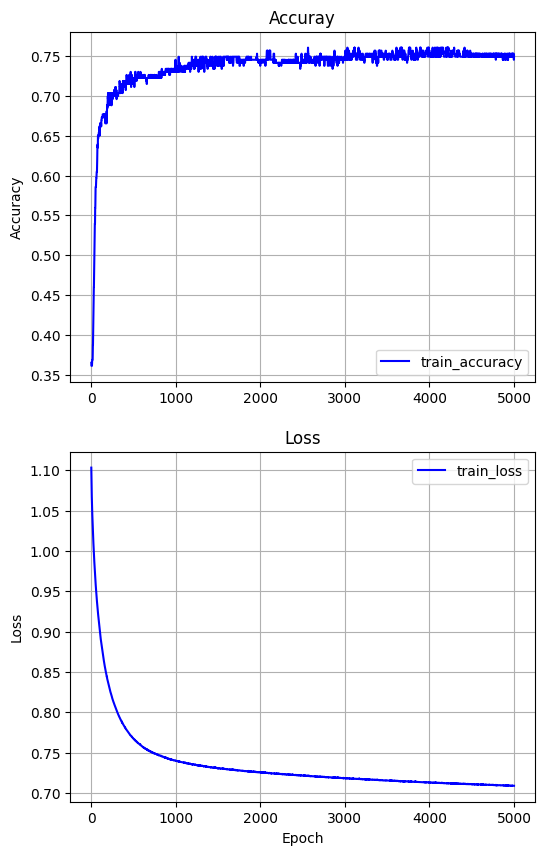

In [17]:
# 4. accuray, loss 그래프 출력
